# FinTrust Week 2 — Exploratory Data Analysis
**Track:** Data Analytics | **Intern:** Miancy (Mercy Chepkemoi Koech)

This notebook explores FinTrust's customer and transaction data to uncover patterns in customer behaviour, transaction activity, channels, and risk.

In [2]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

server = r"localhost\SQLEXPRESS"
database = "FINTRUST DATABASES"

connection = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
)

customers = pd.read_sql("SELECT * FROM dbo.FinTrust_Customer_Data", connection)
transactions = pd.read_sql("SELECT * FROM dbo.FinTrust_Transaction_Data", connection)

connection.close()

print(customers.shape)
print(transactions.shape)

C:\Users\User\AppData\Local\Temp\ipykernel_11156\666537479.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customers = pd.read_sql("SELECT * FROM dbo.FinTrust_Customer_Data", connection)
C:\Users\User\AppData\Local\Temp\ipykernel_11156\666537479.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  transactions = pd.read_sql("SELECT * FROM dbo.FinTrust_Transaction_Data", connection)


(1500, 12)
(12000, 11)


## 1. Customer Segment Distribution

C:\Users\User\AppData\Local\Temp\ipykernel_11156\1451911133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='Blues_d')


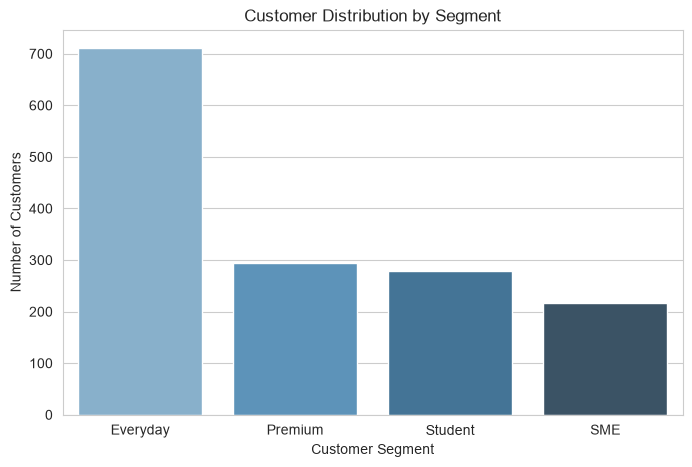

In [3]:
plt.figure(figsize=(8,5))
segment_counts = customers['Customer_Segment'].value_counts()
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='Blues_d')
plt.title('Customer Distribution by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.show()

**What it shows:** The number of customers in each segment (Everyday, Premium, SME, Student).
**Why it matters:** Segment size affects how FinTrust should prioritize resources and campaigns.
**Insight:** Everyday customers dominate the base at ~700 (nearly half of all 1,500 customers), while Premium (~295) and Student (~280) are roughly equal in size, and SME is the smallest (~230). This confirms FinTrust's core customer base is mass-market rather than concentrated in high-value segments, reinforcing the Week 1/SQL finding that Everyday drives the most transaction value — it's both the largest and most active segment.

## 2. Transaction Amount Distribution

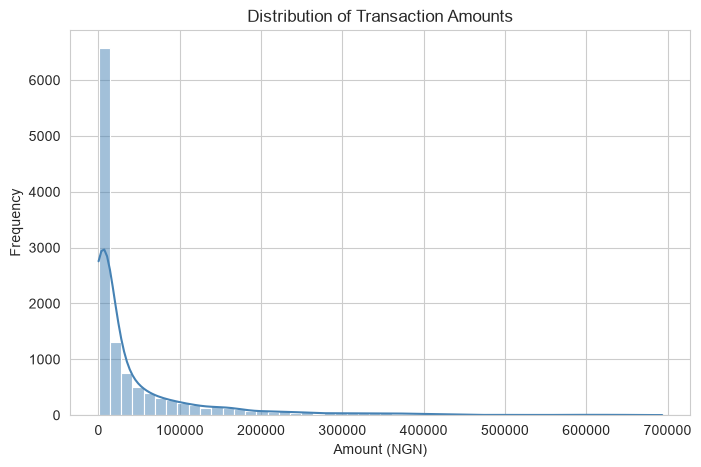

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(transactions['Amount_NGN'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount (NGN)')
plt.ylabel('Frequency')
plt.show()

**What it shows:** How transaction amounts are distributed across all 12,000 transactions.
**Why it matters:** The shape of this distribution affects which statistics (mean vs. median) best represent "typical" transaction behaviour, and reveals how common small vs. large transactions are.
**Insight:** The distribution is heavily right-skewed — the vast majority of transactions cluster under ₦50,000, with a sharp peak in the lowest bucket, then a long tail stretching out to ~₦693,000. This confirms the Week 2 Excel finding (mean ₦46,706 pulled well above the likely lower median) and means average transaction value alone would overstate what a "typical" customer transaction looks like. For reporting, median or segmented averages give a more honest picture than the mean alone.


## 3. Transaction Volume by Channel

C:\Users\User\AppData\Local\Temp\ipykernel_11156\4087973673.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_counts.index, y=channel_counts.values, palette='Greens_d')


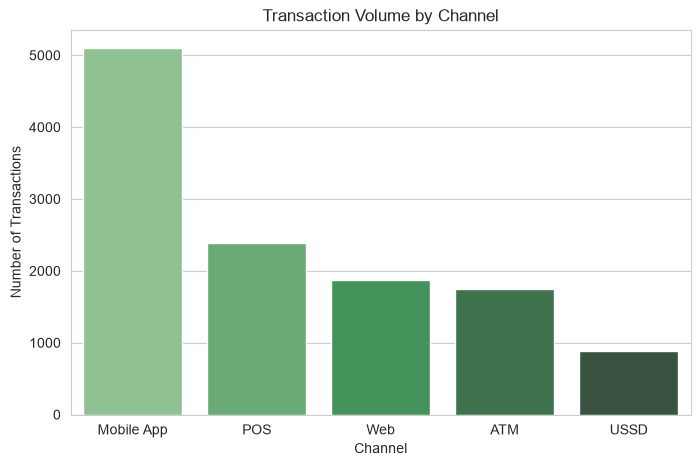

In [5]:
plt.figure(figsize=(8,5))
channel_counts = transactions['Channel'].value_counts()
sns.barplot(x=channel_counts.index, y=channel_counts.values, palette='Greens_d')
plt.title('Transaction Volume by Channel')
plt.xlabel('Channel')
plt.ylabel('Number of Transactions')
plt.show()

**What it shows:** How many transactions occurred through each channel (Mobile App, POS, Web, ATM, USSD).
**Why it matters:** Channel usage patterns should guide where FinTrust invests in platform reliability, UX improvements, and support resources.
**Insight:** Mobile App dominates with ~5,100 transactions — more than double the next-highest channel (POS, ~2,400) — confirming FinTrust customers are primarily digital-first. USSD trails significantly at under 900 transactions, which may reflect either lower demand or a smaller segment of customers who rely on it (often those with limited smartphone/data access). Given Mobile App's outsized share, any reliability or performance issues there would affect the largest number of customers.

## 4. Risk Review Rate: Domestic vs. International Transactions

C:\Users\User\AppData\Local\Temp\ipykernel_11156\2569081837.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_by_intl.index, y=risk_by_intl.values, palette='Reds_d')


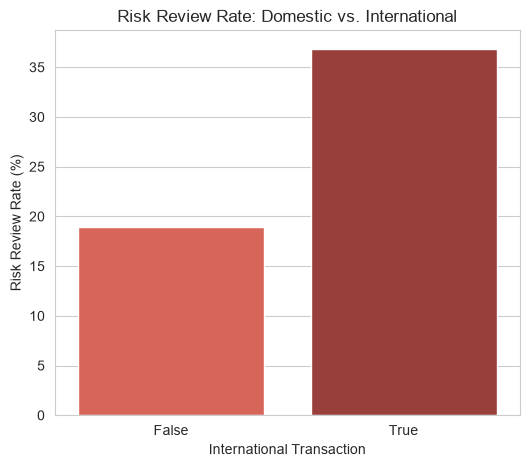

In [7]:
risk_by_intl = transactions.groupby('International_Transaction')['Risk_Review_Flag'].apply(
    lambda x: (x == 1).mean() * 100
)

plt.figure(figsize=(6,5))
sns.barplot(x=risk_by_intl.index, y=risk_by_intl.values, palette='Reds_d')
plt.title('Risk Review Rate: Domestic vs. International')
plt.xlabel('International Transaction')
plt.ylabel('Risk Review Rate (%)')
plt.show()

**What it shows:** The percentage of transactions flagged for risk review, split by whether the transaction was domestic (False) or international (True).
**Why it matters:** This directly tests whether international transactions carry meaningfully higher risk — a key input for how FinTrust allocates risk-monitoring resources.
**Insight:** International transactions are flagged at nearly double the rate of domestic ones (~36.9% vs. ~18.9%), despite making up a small share of total transaction volume. This is the strongest risk signal in the dataset and supports a clear recommendation: FinTrust's risk-review process should weight international transactions more heavily, and any automated risk-scoring model should treat this as a high-importance feature.

## 5. Transaction Status Breakdown

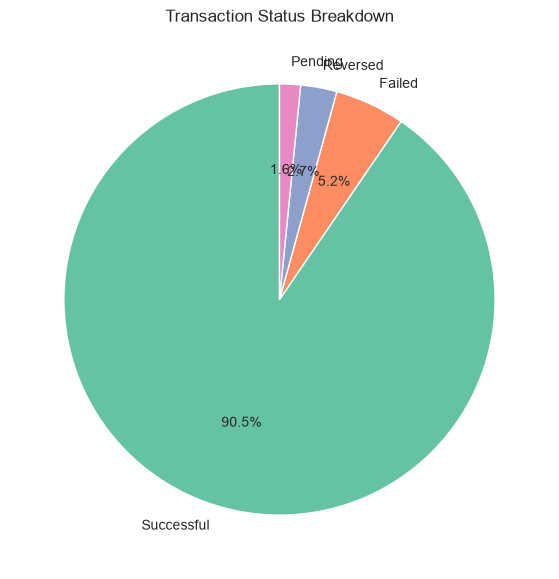

In [8]:
plt.figure(figsize=(7,7))
status_counts = transactions['Transaction_Status'].value_counts()
colors = sns.color_palette('Set2')
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Transaction Status Breakdown')
plt.show()

**What it shows:** The proportion of all transactions by final status (Successful, Failed, Reversed, Pending).
**Why it matters:** Failed and reversed transactions represent friction — customers whose attempted transactions didn't go through cleanly, which can drive support load and erode trust in the platform.
**Insight:** While 90.5% of transactions succeed, the combined 7.9% that are Failed or Reversed (630 + 326 transactions) is a meaningful volume worth investigating — is it concentrated in a particular channel or transaction type? This is a natural follow-up question for Week 3, and a metric FinTrust should track as a reliability KPI going forward.

## Summary of Key Findings

1. **Everyday segment dominates** the customer base (~700 customers) and generates the most transaction value — FinTrust's core business is mass-market, not premium-concentrated.
2. **Transaction amounts are heavily right-skewed** — most transactions are small, with a long tail of high-value outliers; median is more representative than mean.
3. **Mobile App is the dominant channel** (~5,100 transactions), more than double any other channel — platform reliability here has outsized impact.
4. **International transactions carry significantly higher risk** — flagged at ~36.9% vs. ~18.9% for domestic, the strongest risk signal in the dataset.
5. **7.9% of transactions fail or reverse** — a real operational friction point worth deeper investigation in Week 3.

These findings feed directly into the KPI framework and dashboard planned for Week 3.